Sun:
Best log(age): 9.663
Best age: 4.60 Gyr


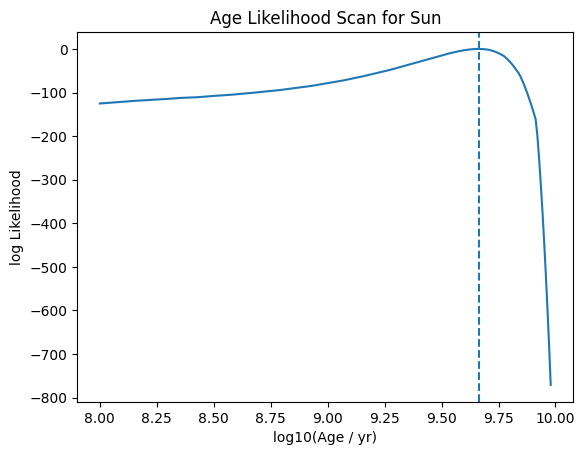

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from isochrones.mist import MIST_Isochrone
mist = MIST_Isochrone()

# load MIST grids
age_grid  = np.linspace(6.0, 10.2, 60)     # 1 Myr → 16 Gyr
feh_grid  = np.linspace(-2.5, 0.5, 31)     # halo → super-solar
mass_grid = np.linspace(0.1, 10.0, 200)    # M dwarfs → massive MS

# build the interpolators
bands = ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'W1_mag', 'W2_mag']
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {band: np.full(shape, np.nan) for band in bands}

for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty:
            continue
        iso = iso.sort_values('initial_mass')
        for band in bands:
            cubes[band][i, j, :] = np.interp(
                mass_grid,
                iso['initial_mass'],
                iso[band],
                left=np.nan,
                right=np.nan
            )

interpolators = {}
for band in bands:
    interpolators[band] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[band],
        bounds_error=False,
        fill_value=np.nan
    )

compare_bands = ['J_mag','K_mag','G_mag','BP_mag','RP_mag']

def get_model_mag(mass, age, feh):
    mags = []
    for band in compare_bands:
        mags.append(interpolators[band]([[age, feh, mass]])[0])
    return np.array(mags)

# likelihood/prior/post functions
def log_likelihood(theta, y, yerr):
    mass, logage, feh = theta
    model = get_model_mag(mass, logage, feh)
    if model is None or np.any(np.isnan(model)):
        return -np.inf
    sigma_model = 0.05
    total_err = np.sqrt(yerr**2 + sigma_model**2)
    chi2 = np.sum(((y - model) / total_err)**2)
    return -0.5 * chi2

def log_prior(theta):
    mass, logage, feh = theta
    if not (0.1 < mass < 2.0):
        return -np.inf
    if not (7.0 < logage < 10.5):
        return -np.inf
    if not (-2.5 < feh < 0.5):
        return -np.inf
    return 0.0

def log_posterior(theta, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, y, yerr)

# solar data example
iso_sun = mist.isochrone(age=9.66, feh=0.0)
sun = iso_sun.iloc[np.argmin(np.abs(iso_sun['initial_mass'] - 1.0))]
y_dict = {band: sun[band] for band in ['J_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag']}
y = np.array([y_dict[b] for b in ['J_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag']])
yerr = np.full_like(y, 0.02)  # example observational uncertainty

# age scan
def scan_age_likelihood(name, y, yerr, mass=1.0, feh=0.0, age_min=6.0, age_max=10.2):
    ages = np.linspace(age_min, age_max, 300)
    logL = []
    
    for a in ages:
        logL.append(log_likelihood([mass, a, feh], y, yerr))
    
    logL = np.array(logL)
    
    # --- find peak ---
    best_idx = np.argmax(logL)
    best_logage = ages[best_idx]
    best_age_yr = 10**best_logage
    
    print(f"{name}:")
    print(f"Best log(age): {best_logage:.3f}")
    print(f"Best age: {best_age_yr/1e9:.2f} Gyr")
    
    # --- plot ---
    plt.plot(ages, logL)
    plt.axvline(best_logage, linestyle='--')
    plt.xlabel("log10(Age / yr)")
    plt.ylabel("log Likelihood")
    plt.title(f"Age Likelihood Scan for {name}")
    plt.show()

scan_age_likelihood("Sun", y, yerr, mass=1.0, feh=0.0, age_min=8.0)

APCol:
Best log(age): 8.641
Best age: 0.44 Gyr


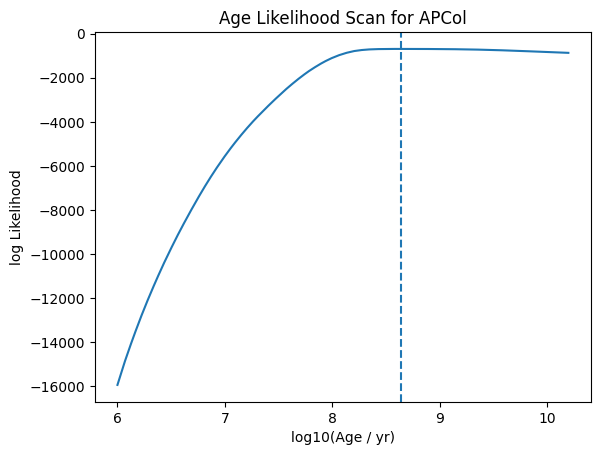

In [21]:
import numpy as np

# AP Col example
# observed apparent magnitudes 
apcol_distance_pc = 8.666  # distance in parsecs
apcol_mags_app = {
    'J_mag': 7.74,
    'K_mag': 6.86,
    'G_mag': 11.11,
    'BP_mag': 13.17,
    'RP_mag': 9.77
}

def apparent_to_absolute(m_app, distance_pc):
    return m_app - 5 * np.log10(distance_pc / 10.0)

apcol_mags_abs = {band: apparent_to_absolute(m, apcol_distance_pc) 
                  for band, m in apcol_mags_app.items()}

y_apcol = np.array([apcol_mags_abs[b] for b in compare_bands])
yerr_apcol = np.full_like(y_apcol, 0.02) 

# mass ~0.3 Msun, assume [Fe/H] ~0.0
scan_age_likelihood("APCol", y_apcol, yerr_apcol, mass=0.3, feh=0.0, age_min=6.0)

HD209458:
Best log(age): 9.467
Best age: 2.93 Gyr


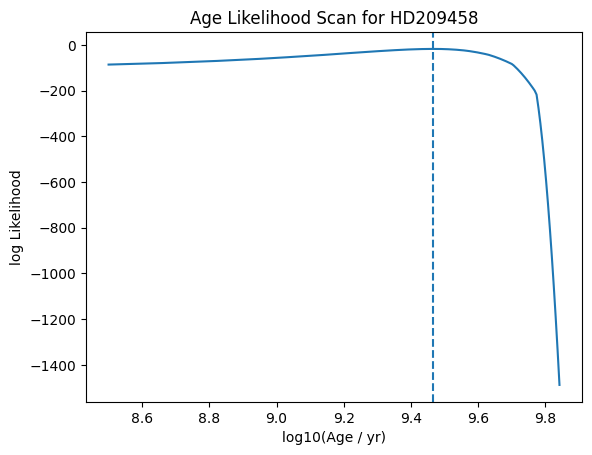

In [22]:
hd209458_distance_pc = 49.6  # from parallax

hd209458_mags_app = {
    'J_mag': 6.59,
    'K_mag': 6.31,
    'G_mag': 7.65,
    'BP_mag': 8.10,
    'RP_mag': 7.05
}

def apparent_to_absolute(m_app, distance_pc):
    return m_app - 5 * np.log10(distance_pc / 10.0)

hd209458_mags_abs = {
    band: apparent_to_absolute(m, hd209458_distance_pc)
    for band, m in hd209458_mags_app.items()
}

y_hd = np.array([hd209458_mags_abs[b] for b in compare_bands])
yerr_hd = np.full_like(y_hd, 0.02)

scan_age_likelihood('HD209458', y_hd, yerr_hd, mass=1.1, feh=0.0, age_min=8.5)